# Vanishing Gradient en RNN Básicas

Este notebook muestra el efecto de secuencias largas sobre una `RNN` básica y cómo se atenúa la señal de error cuando se propaga hacia estados muy lejanos en el tiempo.



## Librerías y configuración general


In [37]:
# Importamos librerías para datos, entrenamiento, gradientes y visualización.

import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error


In [38]:
# Fijamos semillas para reproducibilidad y detectamos el dispositivo.

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usaremos el dispositivo: {device}')


Usaremos el dispositivo: cuda


## Parámetros globales


In [39]:
# Configuramos el largo base de secuencia y otros parámetros globales del experimento.

N_STEPS_BASE = 50
N_FUTURE = 1
TOTAL_SAMPLES = 10000
BATCH_SIZE = 64
N_EPOCHS = 20
print(f'Contexto base configurado en {N_STEPS_BASE} pasos')


Contexto base configurado en 50 pasos


## Señal y utilidades compartidas

La señal mantiene el mismo espiritu que en la clase.


In [40]:
# Generamos la serie temporal sintética usada por todos los experimentos del bloque.

def generate_time_series_simple(batch_size, n_steps, n_future):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps + n_future)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    series += 0.1 * (np.random.rand(batch_size, n_steps + n_future) - 0.5)
    return series[..., np.newaxis].astype(np.float32)


In [41]:
# Función para visualizar secuencias, targets y predicciones.

def plot_series(series, y=None, y_pred=None, rows=3, cols=4, title=None):
    series_main = series[:, :, 0]
    if y is not None and y.ndim == 3:
        y = y[:, :, 0]
    if y_pred is not None and isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().cpu().numpy()
    if y_pred is not None and y_pred.ndim == 3:
        y_pred = y_pred[:, :, 0]

    total = min(rows * cols, len(series_main))
    fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharex=True, sharey=True)
    axes = np.array(axes).reshape(rows, cols)

    for idx in range(rows * cols):
        ax = axes[idx // cols, idx % cols]
        if idx >= total:
            ax.axis('off')
            continue

        x = series_main[idx]
        ax.plot(np.arange(len(x)), x, '.-', label='input')
        if y is not None:
            ax.plot(np.arange(len(x), len(x) + y.shape[1]), y[idx], 'bx', markersize=7, label='target')
        if y_pred is not None:
            ax.plot(np.arange(len(x), len(x) + y_pred.shape[1]), y_pred[idx], 'ro', markersize=4, label='pred')
        ax.grid(True)
        ax.axhline(0.0, linewidth=1, color='gray')

    if title is not None:
        fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [42]:
# Graficamos train/eval loss dentro del notebook para comparar contextos.

def plot_histories(histories, title='Curvas de entrenamiento'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for label, history in histories.items():
        axes[0].plot(history['train_loss'], label=label)
        axes[1].plot(history['eval_loss'], label=label)

    axes[0].set_title('Train loss')
    axes[1].set_title('Validation loss')
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE')
        ax.grid(True)
        ax.legend()
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [43]:
# Dataset sencillo para entrenar y evaluar las RNN del experimento.

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X = X
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        if self.train:
            y = torch.from_numpy(self.y[idx])
            return x, y
        return x


In [44]:
# Preparamos train, validation y test para una longitud de secuencia dada.

def prepare_dataset(n_steps, total_samples=TOTAL_SAMPLES, batch_size=BATCH_SIZE, verbose=True):
    series = generate_time_series_simple(total_samples, n_steps, N_FUTURE)
    X_train, y_train = series[:7000, :n_steps], series[:7000, -N_FUTURE:]
    X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -N_FUTURE:]
    X_test, y_test = series[9000:, :n_steps], series[9000:, -N_FUTURE:]

    if verbose:
        print('X_train, y_train:', X_train.shape, y_train.shape)
        print('X_valid, y_valid:', X_valid.shape, y_valid.shape)
        print('X_test, y_test:', X_test.shape, y_test.shape)

    datasets = {
        'train': TimeSeriesDataset(X_train, y_train, train=True),
        'eval': TimeSeriesDataset(X_valid, y_valid, train=True),
        'test': TimeSeriesDataset(X_test, y_test, train=False),
    }

    dataloaders = {
        'train': DataLoader(datasets['train'], batch_size=batch_size, shuffle=True),
        'eval': DataLoader(datasets['eval'], batch_size=batch_size, shuffle=False),
        'test': DataLoader(datasets['test'], batch_size=batch_size, shuffle=False),
    }

    arrays = {
        'X_train': X_train, 'y_train': y_train,
        'X_valid': X_valid, 'y_valid': y_valid,
        'X_test': X_test, 'y_test': y_test,
    }
    return datasets, dataloaders, arrays


## Preparación del dataset


X_train, y_train: (7000, 50, 1) (7000, 1, 1)
X_valid, y_valid: (2000, 50, 1) (2000, 1, 1)
X_test, y_test: (1000, 50, 1) (1000, 1, 1)


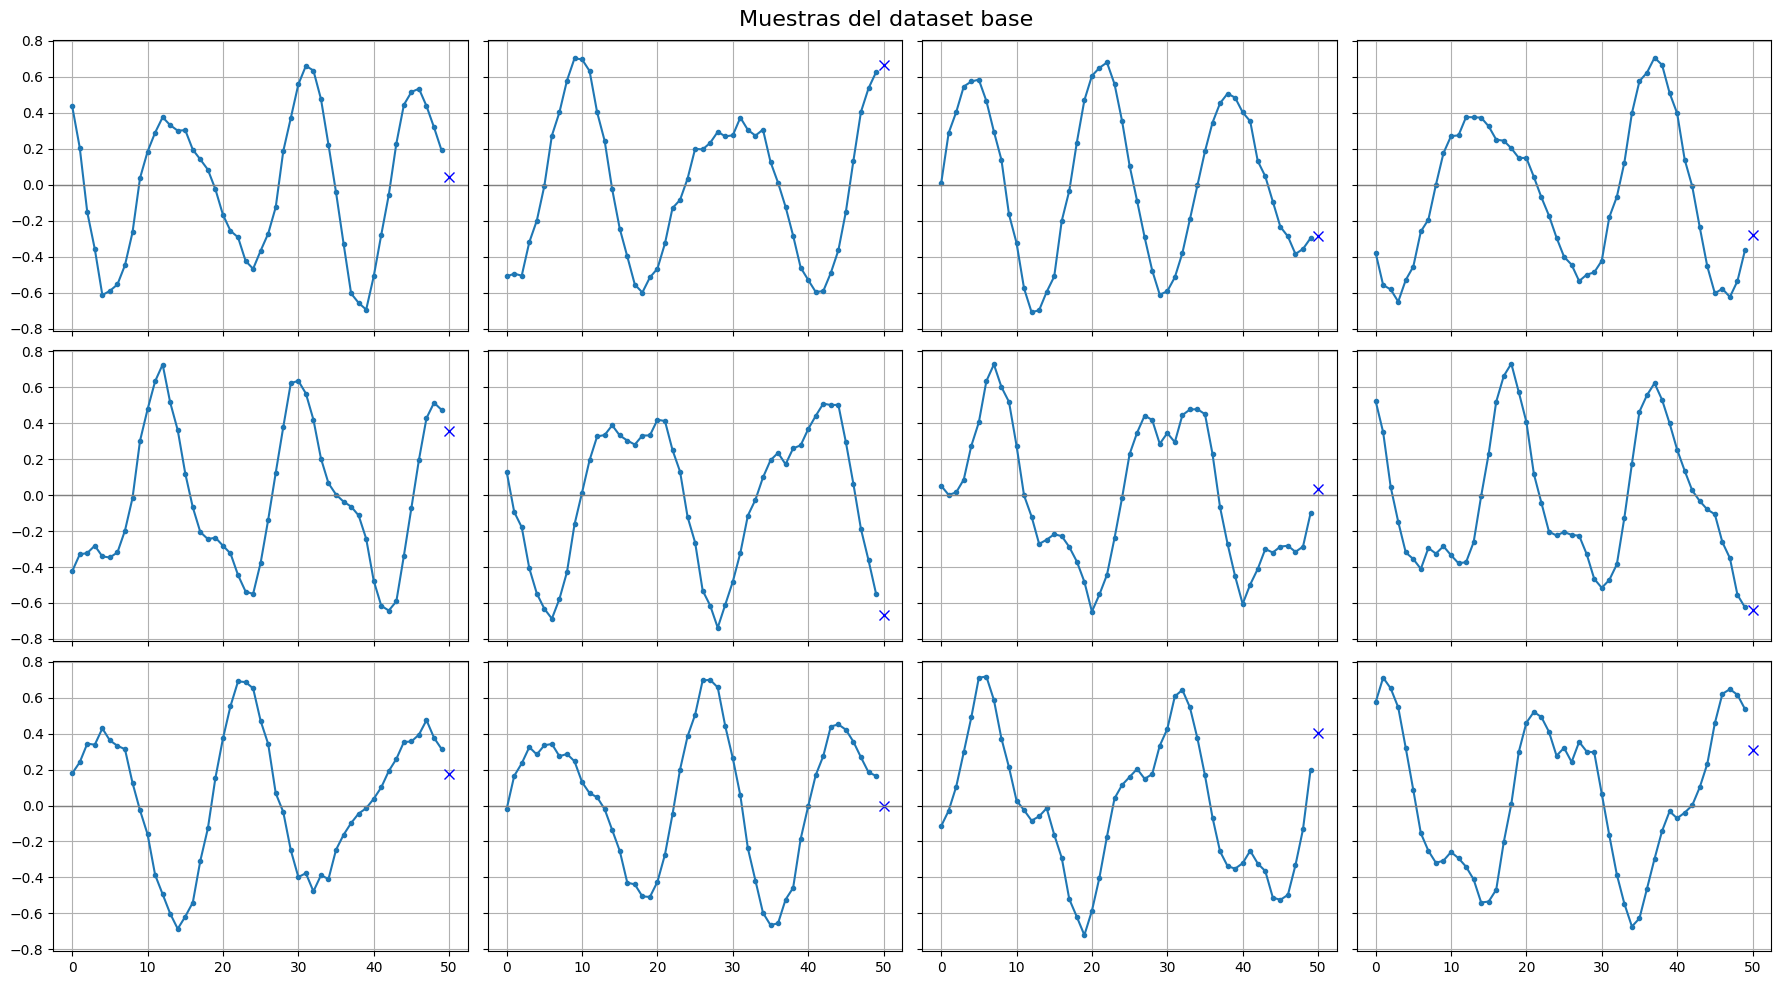

In [45]:
# Generamos y visualizamos el dataset base del experimento.

dataset_base, dataloader_base, arrays_base = prepare_dataset(N_STEPS_BASE)
plot_series(arrays_base['X_test'], y=arrays_base['y_test'], title='Muestras del dataset base')


## Modelo RNN

Usamos una `RNN` básica con activación `tanh` y una capa lineal final, consistente con el resto de la clase.


In [46]:
# Definimos una RNN b?sica coherente con el resto de la clase.

class SimpleRNNRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, n_out=1, activation='tanh'):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.activation = activation
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=activation,
            batch_first=True,
        )
        self.readout = nn.Linear(hidden_size, n_out)

    def forward(self, x, h0=None):
        rnn_out, _ = self.rnn(x, h0)
        last_hidden = rnn_out[:, -1, :]
        return self.readout(last_hidden)


In [47]:
# Rutina de entrenamiento y predicción para el problema de 1 paso futuro.

def fit(model, dataloaders, epochs=N_EPOCHS, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()
    history = {'train_loss': [], 'eval_loss': []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        bar = tqdm(dataloaders['train'], leave=False)
        for X, y in bar:
            X = X.to(device)
            y = y.to(device).view(y.shape[0], -1)
            optimizer.zero_grad()
            pred = model(X)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            bar.set_description(f'train {np.mean(train_losses):.5f}')

        model.eval()
        eval_losses = []
        with torch.no_grad():
            for X, y in dataloaders['eval']:
                X = X.to(device)
                y = y.to(device).view(y.shape[0], -1)
                pred = model(X)
                loss = criterion(pred, y)
                eval_losses.append(loss.item())

        history['train_loss'].append(float(np.mean(train_losses)))
        history['eval_loss'].append(float(np.mean(eval_losses)))
    return history


def predict(model, dataloader, reduced=0):
    model.eval()
    preds = []
    first_batch = True
    with torch.no_grad():
        for X in dataloader:
            if reduced > 0:
                X = X[:, -reduced:, :]
            if first_batch:
                print('X shape empleado para predecir:')
                print(tuple(X.shape))
                first_batch = False
            X = X.to(device)
            pred = model(X)
            preds.append(pred.detach().cpu())
    return torch.cat(preds, dim=0)


## Entrenamiento base con el contexto global


In [48]:
# Entrenamos el modelo base con el contexto completo y medimos su MSE.

def train_context(seq_len, epochs=N_EPOCHS):
    dataset, dataloaders, arrays = prepare_dataset(seq_len, batch_size=BATCH_SIZE, verbose=False)
    model = SimpleRNNRegressor(input_size=1, hidden_size=32, num_layers=2, n_out=N_FUTURE)
    history = fit(model, dataloaders, epochs=epochs, lr=1e-3)
    y_pred = predict(model, dataloaders['test'], reduced=0).cpu().numpy()
    mse = mean_squared_error(np.squeeze(arrays['y_test']), np.squeeze(y_pred))
    return {
        'seq_len': seq_len,
        'model': model,
        'dataloaders': dataloaders,
        'arrays': arrays,
        'history': history,
        'mse': mse,
    }


experiment_base = train_context(N_STEPS_BASE)
print(f'MSE en test para {experiment_base["seq_len"]} pasos: {experiment_base["mse"]:.6f}')


X shape empleado para predecir:
(64, 50, 1)
MSE en test para 50 pasos: 0.003004


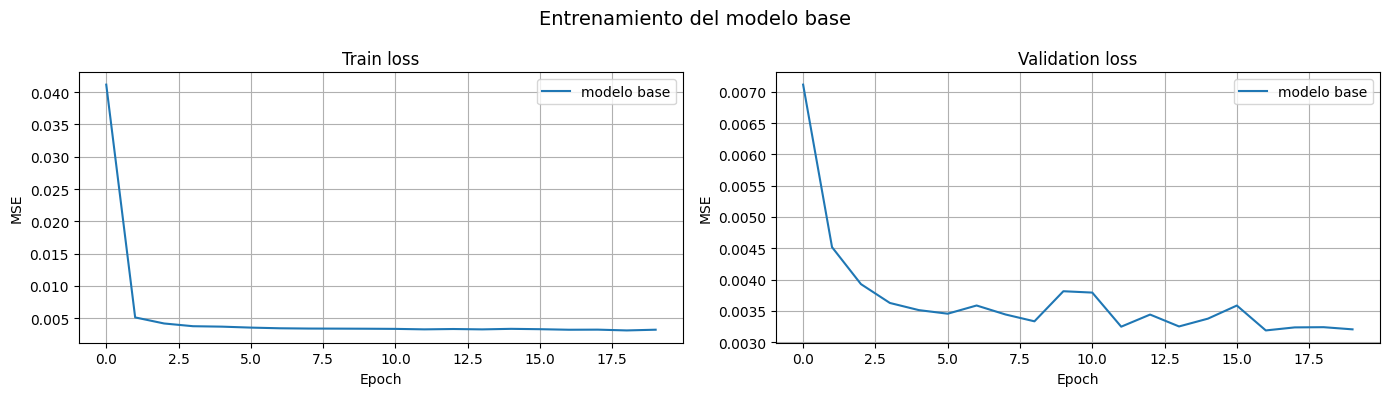

In [49]:
# Graficamos las curvas de entrenamiento del modelo base.

plot_histories({'modelo base': experiment_base['history']}, title='Entrenamiento del modelo base')


## Experimento de gradientes

Medimos c?mo se aten?an los gradientes de los pesos recurrentes (`W_hh`) y del estado inicial (`h0`) al variar la longitud de la secuencia.

La curva m?s interpretativa suele ser `||grad h0||`, porque muestra cu?nta se?al de error logra viajar hacia el inicio de la secuencia.

La curva `||grad W_hh||` no se reduce tanto porque los gradientes de las muestras pr?ximas a la actual tambi?n aportan al gradiente total.

Importante: en las comparaciones siguientes conviene distinguir entre el **contexto con el que se entren?** el modelo y la **longitud con la que luego se lo eval?a**. Un modelo entrenado con 30 pasos puede verse peor cuando se lo prueba con secuencias mucho m?s largas, no porque 30 sea siempre peor, sino porque est? siendo llevado fuera del r?gimen temporal que aprendi? durante el entrenamiento.


In [ ]:
# Medimos cómo caen las normas del gradiente al aumentar la longitud de la secuencia.

def gradient_decay_experiment(model, seq_lengths, repeats=5, batch_size=BATCH_SIZE):
    stats = []
    criterion = nn.MSELoss()
    was_training = model.training
    model.train()
    try:
        with torch.backends.cudnn.flags(enabled=False):
            for seq_len in seq_lengths:
                weight_norms = []
                h0_norms = []
                for _ in range(repeats):
                    batch = generate_time_series_simple(batch_size, seq_len, N_FUTURE)
                    X = torch.from_numpy(batch[:, :seq_len, :]).to(device)
                    y = torch.from_numpy(batch[:, -N_FUTURE:, :]).to(device)
                    # se define h0 con requires_grad=True para medir su gradiente, aunque no se actualice en este experimento.
                    # la idea es poder observar cómo decae el gradiente respecto a la entrada oculta inicial, que es la que 
                    # se propaga a través de toda la secuencia.
                    # Al definirpor fuera h0, lo podremos observar luego.
                    h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size, device=device, requires_grad=True)
                    pred = model(X, h0=h0)
                    loss = criterion(pred, y.view(y.shape[0], -1))
                    loss.backward()
                    # acá medimos la norma del gradiente de los pesos recurrentes y de h0, 
                    # que es el que se propaga a través de toda la secuencia.
                    weight_norms.append(model.rnn.weight_hh_l0.grad.detach().norm().item())
                    h0_norms.append(h0.grad.detach().norm().item())
                    model.zero_grad(set_to_none=True)

                stats.append({
                    'seq_len': seq_len,
                    'weight_grad_norm': float(np.mean(weight_norms)),
                    'h0_grad_norm': float(np.mean(h0_norms)),
                })
    finally:
        if not was_training:
            model.eval()
    return stats


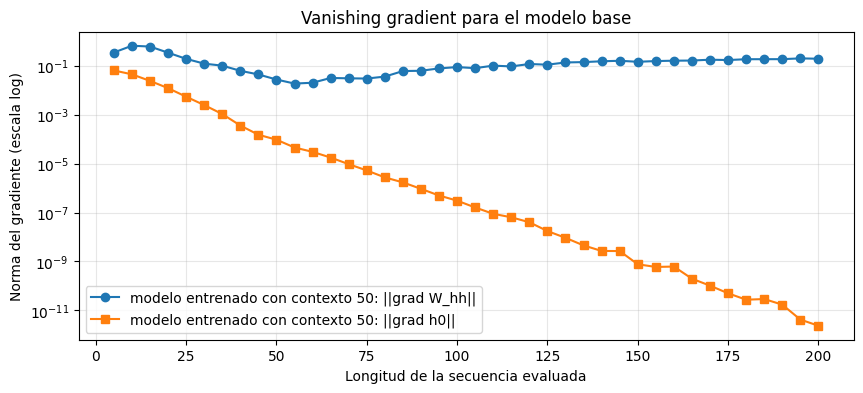

Contexto sugerido por la heurística de quiebre: 30 pasos (threshold 3.27e-03)


In [55]:
# Ejecutamos el experimento de gradientes y estimamos un quiebre heurístico.
# este quiebre se asume como valor a partir del cual, el aporte de las muestras del pasado se consideran
# despresiables. 

seq_lengths = list(range(5, 205, 5))
grad_stats = gradient_decay_experiment(experiment_base['model'], seq_lengths, repeats=5, batch_size=BATCH_SIZE)

lengths = [row['seq_len'] for row in grad_stats]
weight_norms = [row['weight_grad_norm'] for row in grad_stats]
h0_norms = [row['h0_grad_norm'] for row in grad_stats]

plt.figure(figsize=(10, 4))
plt.plot(lengths, weight_norms, marker='o', label='modelo entrenado con contexto 50: ||grad W_hh||')
plt.plot(lengths, h0_norms, marker='s', label='modelo entrenado con contexto 50: ||grad h0||')
plt.yscale('log')
plt.xlabel('Longitud de la secuencia evaluada')
plt.ylabel('Norma del gradiente (escala log)')
plt.title('Vanishing gradient para el modelo base')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

break_threshold = max(h0_norms[0] * 0.05, 1e-3)
short_context = N_STEPS_BASE
for row in grad_stats:
    if row['h0_grad_norm'] <= break_threshold:
        short_context = row['seq_len']
        break

print(f'Contexto sugerido por la heurística de quiebre: {short_context} pasos (threshold {break_threshold:.2e})')
if short_context >= N_STEPS_BASE:
    print('No se detectó un quiebre antes del contexto base; se reutilizará el largo original.')


## Reentrenamiento con contexto acotado

Usamos el largo sugerido por la heurística como una regla práctica, no como un criterio universal ni como el contexto óptimo garantizado.

La idea es comparar empíricamente si reducir el contexto afecta de forma importante el `MSE` o si solo mejora la eficiencia.

En otras palabras: la curva de gradiente sugiere dónde la señal de error empieza a debilitarse mucho, pero la decisión final sobre el contexto útil se valida mirando el desempeño del modelo.


In [57]:
# Reentrenamos una RNN usando el contexto sugerido por la heurística y comparamos MSE.

experiment_short = train_context(short_context)
print(f'MSE en test para {experiment_short["seq_len"]} pasos: {experiment_short["mse"]:.6f}')
print('Comparación directa')
print(f'MSE base = {experiment_base["mse"]:.6f}')
print(f'MSE corto = {experiment_short["mse"]:.6f}')



X shape empleado para predecir:
(64, 30, 1)
MSE en test para 30 pasos: 0.004162
Comparación directa
MSE base = 0.003004
MSE corto = 0.004162


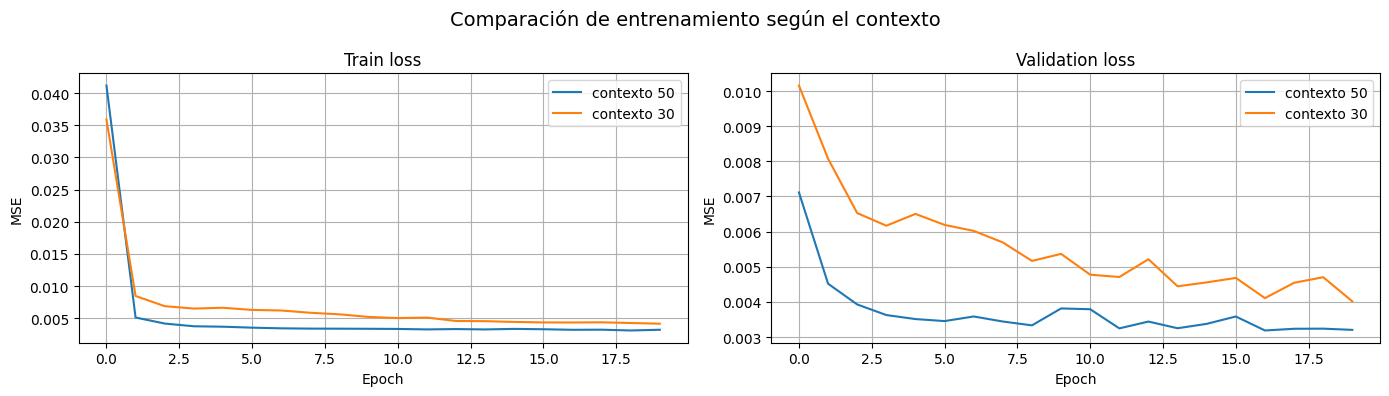

In [58]:
# Comparamos gráficamente las curvas de entrenamiento del contexto largo y el recortado.

plot_histories(
    {
        f'contexto {experiment_base["seq_len"]}': experiment_base['history'],
        f'contexto {experiment_short["seq_len"]}': experiment_short['history'],
    },
    title='Comparación de entrenamiento según el contexto',
)


## Gradientes del modelo corto vs. modelo base


## Error de predicción según el largo del contexto

Además de mirar gradientes, conviene medir directamente el error de predicci?n. En esta prueba generamos **un único conjunto de test largo de 60 pasos** y luego evaluamos ambos modelos usando recortes de sus últimas `20`, `30`, `40`, `50` y `60` muestras.

De esta forma, la comparación se hace sobre las mismas señales base y lo único que cambia es cuánto contexto dejamos visible para la predicción.


X shape empleado para predecir:
(64, 20, 1)
X shape empleado para predecir:
(64, 30, 1)
X shape empleado para predecir:
(64, 40, 1)
X shape empleado para predecir:
(64, 50, 1)
X shape empleado para predecir:
(64, 60, 1)
X shape empleado para predecir:
(64, 20, 1)
X shape empleado para predecir:
(64, 30, 1)
X shape empleado para predecir:
(64, 40, 1)
X shape empleado para predecir:
(64, 50, 1)
X shape empleado para predecir:
(64, 60, 1)


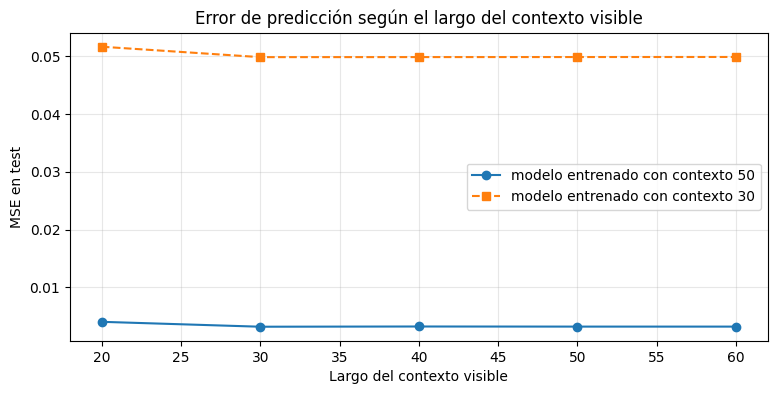

Resumen de MSE por largo de contexto visible:
L=20 | contexto 50: 0.004035 | contexto 30: 0.051634
L=30 | contexto 50: 0.003186 | contexto 30: 0.049832
L=40 | contexto 50: 0.003225 | contexto 30: 0.049841
L=50 | contexto 50: 0.003207 | contexto 30: 0.049849
L=60 | contexto 50: 0.003206 | contexto 30: 0.049860


In [20]:
# Evaluamos ambos modelos sobre el mismo conjunto de test largo y variamos cuánto contexto final usamos.

def evaluate_model_across_contexts(model, dataloader_long, y_true_long, context_lengths):
    mse_values = []
    for context_len in context_lengths:
        y_pred = predict(model, dataloader_long, reduced=context_len).cpu().numpy()
        mse = mean_squared_error(np.squeeze(y_true_long), np.squeeze(y_pred))
        mse_values.append(float(mse))
    return mse_values


context_lengths_eval = [20, 30, 40, 50, 60]
long_context = max(context_lengths_eval)
_, dataloaders_long, arrays_long = prepare_dataset(long_context, batch_size=BATCH_SIZE, verbose=False)

mse_base_by_context = evaluate_model_across_contexts(
    experiment_base['model'],
    dataloaders_long['test'],
    arrays_long['y_test'],
    context_lengths_eval,
)
mse_short_by_context = evaluate_model_across_contexts(
    experiment_short['model'],
    dataloaders_long['test'],
    arrays_long['y_test'],
    context_lengths_eval,
)

plt.figure(figsize=(9, 4))
plt.plot(context_lengths_eval, mse_base_by_context, "o-", label=f"modelo entrenado con contexto {experiment_base['seq_len']}")
plt.plot(context_lengths_eval, mse_short_by_context, "s--", label=f"modelo entrenado con contexto {experiment_short['seq_len']}")
plt.xlabel('Largo del contexto visible')
plt.ylabel('MSE en test')
plt.title('Error de predicción según el largo del contexto visible')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('Resumen de MSE por largo de contexto visible:')
for seq_len, mse_base, mse_short in zip(context_lengths_eval, mse_base_by_context, mse_short_by_context):
    print(f"L={seq_len:>2} | contexto {experiment_base['seq_len']}: {mse_base:.6f} | contexto {experiment_short['seq_len']}: {mse_short:.6f}")


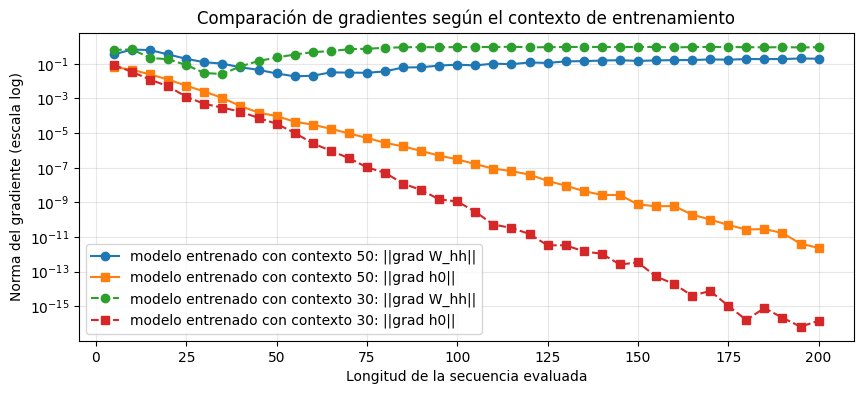

Resumen del modelo corto:
L=  5 -> ||grad W_hh||=6.35e-01 | ||grad h0||=8.57e-02
L= 30 -> ||grad W_hh||=2.97e-02 | ||grad h0||=4.88e-04
L= 55 -> ||grad W_hh||=3.45e-01 | ||grad h0||=1.02e-05
L= 80 -> ||grad W_hh||=8.39e-01 | ||grad h0||=5.09e-08
L=105 -> ||grad W_hh||=9.43e-01 | ||grad h0||=2.83e-10
L=130 -> ||grad W_hh||=9.40e-01 | ||grad h0||=3.32e-12
L=155 -> ||grad W_hh||=9.48e-01 | ||grad h0||=5.28e-14
L=180 -> ||grad W_hh||=9.21e-01 | ||grad h0||=1.60e-16


In [60]:
# Superponemos las curvas de gradiente de ambos modelos para leer mejor el efecto del contexto.

grad_stats_short = gradient_decay_experiment(experiment_short['model'], seq_lengths, repeats=5, batch_size=256)

weight_norms_short = [row['weight_grad_norm'] for row in grad_stats_short]
h0_norms_short = [row['h0_grad_norm'] for row in grad_stats_short]

plt.figure(figsize=(10, 4))
plt.plot(lengths, weight_norms, 'o-', label=f'modelo entrenado con contexto {experiment_base["seq_len"]}: ||grad W_hh||')
plt.plot(lengths, h0_norms, 's-', label=f'modelo entrenado con contexto {experiment_base["seq_len"]}: ||grad h0||')
plt.plot(lengths, weight_norms_short, 'o--', label=f'modelo entrenado con contexto {short_context}: ||grad W_hh||')
plt.plot(lengths, h0_norms_short, 's--', label=f'modelo entrenado con contexto {short_context}: ||grad h0||')
plt.yscale('log')
plt.xlabel('Longitud de la secuencia evaluada')
plt.ylabel('Norma del gradiente (escala log)')
plt.title('Comparación de gradientes según el contexto de entrenamiento')
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='lower left')
plt.show()

print('Resumen del modelo corto:')
for row in grad_stats_short[::5]:
    print(f'L={row["seq_len"]:>3} -> ||grad W_hh||={row["weight_grad_norm"]:.2e} | ||grad h0||={row["h0_grad_norm"]:.2e}')


## Observaciones finales

- El gradiente del estado inicial puede caer varias órdenes de magnitud cuando la secuencia se hace larga.
- Si el gradiente hacia estados muy lejanos se vuelve despreciable, la red tiene dificultades para aprovechar dependencias tan largas.
- Si el modelo entrenado con contexto 30 muestra peor `||grad h0||` al evaluarlo en longitudes grandes, eso no significa que "las secuencias más cortas sean peores" en general: significa que ese modelo quedó menos preparado para sostener gradientes fuera del rango temporal con el que fue entrenado.
- En cambio, un modelo entrenado con contexto 50 ya recibió presión de entrenamiento para propagar información útil durante más pasos, por lo que suele degradarse menos cuando se lo evalúa con secuencias largas.
- Por eso, el análisis de gradientes y la comparación de `MSE` deben leerse en conjunto: el primero da una señal diagnóstica y el segundo valida el impacto real sobre la predicción.
- Si el problema realmente requiere dependencias largas, conviene pasar a arquitecturas con mecanismos de gating (`GRU`/`LSTM`) o usar estrategias que mitiguen el `vanishing gradient`.
